In [48]:
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import albumentations as A
import requests
from io import BytesIO
from PIL import Image
import random
import torch
from tqdm.notebook import tqdm
import torch.nn as nn 
from torch._C import device
import torch.optim as optim
import torch.autograd.grad_mode as grad_mode
from torch.utils.data import Dataset,DataLoader
from torch.autograd import Function as F 
import torchvision
from torchvision.models.detection.faster_rcnn import FastRCNNPredictor
from torchvision.models.detection import FasterRCNN
from torchvision.models.detection import fasterrcnn_resnet50_fpn
from torchvision.models.detection.rpn import AnchorGenerator
import warnings
warnings.filterwarnings('ignore')

In [49]:
if torch.cuda.is_available():
    device=torch.device("cuda")
else:
    device=torch.device('cpu')

In [50]:
device

device(type='cuda')

In [51]:
def imageshow(number,title=None,size=5):
    root="../data/"
    image=cv2.imread(root+'Images/'+str(number)+".jpeg")
    
    file=open(root+"Labels/"+str(number)+".txt",'r')
    txt_data=file.readlines()
    file.close()
    
    for i in range(0,int(txt_data[0])):
        indices=[int(x) for x in txt_data[i+1].split()]
        start_point=(indices[0],indices[1])
        end_point=(indices[2],indices[3])
        
        cv2.rectangle(image,start_point,end_point,(0,0,255),2)
        
    aspect_ratio=image.shape[0]/image.shape[1]
    
    plt.figure(figsize=(size+aspect_ratio,size))
    plt.imshow(cv2.cvtColor(image,cv2.COLOR_BGR2RGB))
    plt.title(title+txt_data[0])
    plt.show()

    

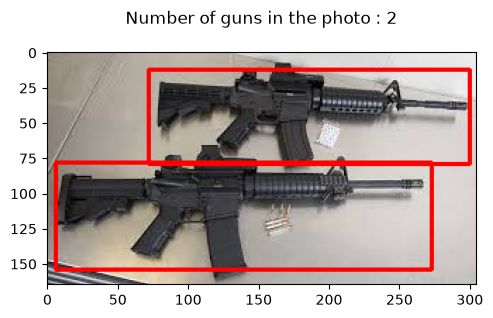

In [52]:
imageshow(119,title="Number of guns in the photo : ")

In [53]:
import os

In [54]:
class Gun_Data(Dataset):

    def __init__(self,root):
        self.image_path = root+"Images/"
        self.labels_path = root+"Labels/"

        self.img_name = [img for img in sorted(os.listdir(self.image_path))]
        self.label_name = [label for label in sorted(os.listdir(self.labels_path))]

    def __getitem__(self,idx):
        image_path =  os.path.join(self.image_path , str(self.img_name[idx]))
        image = cv2.imread(image_path)
        img_rgb = cv2.cvtColor(image,cv2.COLOR_BGR2RGB).astype(np.float32)

        img_res = img_rgb/255
        img_res = torch.as_tensor(img_res).permute(2,0,1)

        label_name  = self.img_name[idx][:-4] + "txt"
        label_path = os.path.join(self.labels_path , str(label_name))

        with open(label_path,"r") as label_file:
            l_count = int(label_file.readline())
            box=[]
            for i in range(l_count):
                box.append(list(map(int,label_file.readline().split())))
                
        target={}
        area=[]
        labels=[]

        for i in range(len(box)):
            a = (box[i][2] - box[i][0]) * (box[i][3] -  box[i][1])
            area.append(a)

        for i in range(len(box)):
            labels.append(1)

        target["boxes"] = torch.as_tensor(box)
        target["area"] =  torch.as_tensor(area)
        target["image_id"] = torch.as_tensor([idx])
        target["labels"] = torch.as_tensor(labels , dtype=torch.int64)

        img_res = img_res.to(device)
        for key in target:
            if isinstance(target[key] , torch.Tensor):
                target[key] = target[key].to(device)

        return img_res,target

    def __len__(self):
        return len(self.img_name)
    

In [55]:
class Model:
    def __init__(self,num):
        self.num=num
        self.model=self.create_model()
        
    def create_model(self):
        model=fasterrcnn_resnet50_fpn(pretrained=True)
        
        in_features=model.roi_heads.box_predictor.cls_score.in_features
        
        model.roi_heads.box_predictor=FastRCNNPredictor(in_features,self.num)
        
        return model
    
    def complier(self,optimizer):
        self.optimizer=optimizer
    
    def train(self,train_data,val_data):
        for epoch in tqdm(range(num_epoch)):
            self.model=self.model.to(device)
            
            train_loss=0
            self.model.train()
            for img,target in train_data:
                loss_dic=self.model(img,target)
                loss=sum(loss for loss in loss_dic.values())
                
                self.optimizer.zero_grad()
                loss.backward()
                
                self.optimizer.step()
                train_loss+=loss
                
            print(f"Epoch : {epoch+1} | Train Loss  : {train_loss}")
            

In [56]:
from torch.utils.data import random_split

In [57]:
rcnn=Model(2)
model=rcnn.model
optimizer=optim.Adam(model.parameters(),lr=0.0001)
num_epoch=30
rcnn.complier(optimizer)

def collate_fn(batch):
    return tuple(zip(*batch))


dataset = Gun_Data("../data/")


train_size=int(0.8*len(dataset))
val_size=len(dataset)-train_size

train_dataset,val_dataset=random_split(dataset,[train_size,val_size]) 

import gc

gc.collect()
torch.cuda.empty_cache()

train_loader=DataLoader(train_dataset,batch_size=1,shuffle=True,num_workers=0,collate_fn=collate_fn)
val_loader=DataLoader(val_dataset,batch_size=1,shuffle=True,num_workers=0,collate_fn=collate_fn)

Downloading: "https://download.pytorch.org/models/fasterrcnn_resnet50_fpn_coco-258fb6c6.pth" to /home/zaheer/.cache/torch/hub/checkpoints/fasterrcnn_resnet50_fpn_coco-258fb6c6.pth
100%|██████████| 160M/160M [01:25<00:00, 1.96MB/s] 


In [58]:
torch.cuda.empty_cache()

In [ ]:
rcnn.train(train_loader,val_loader)

  0%|          | 0/30 [00:00<?, ?it/s]

Epoch : 1 | Train Loss  : 65.15470123291016
Epoch : 2 | Train Loss  : 57.51551055908203
Epoch : 3 | Train Loss  : 54.46336364746094
Epoch : 4 | Train Loss  : 47.24601364135742
Epoch : 5 | Train Loss  : 40.67277526855469
